# ResNet-18

## Changes from Naive Baseline

### What changed
| | Naive | Unfreeze |
|---|---|---|
| Backbone | Frozen (only FC trains) | Unfrozen (all layers train) |
| Optimizer scope | `model.fc.parameters()` | `model.parameters()` |
| Learning rate | `1e-3` | `1e-4` |

### Rationale
In the naive version, the ResNet backbone was frozen — only the final classification layer (513 parameters out of ~11M) was trained. The backbone weights were fixed at ImageNet features, which are general-purpose and not specific to skin lesions.

By unfreezing the backbone, all ~11M parameters are fine-tuned on the HAM10000 dataset, allowing the model to adapt its feature extraction to the medical imaging domain.

A lower learning rate (`1e-4`) is used to avoid destroying the pretrained weights with large gradient updates early in training — the goal is to make small, careful adjustments to already-useful features rather than learning from scratch.

In [ ]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch

In [2]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('data_new/splits/train.csv')

num_melanoma = (train_df['label'] == 1).sum()   # melanoma in CSV (label=1)
num_nevus = (train_df['label'] == 0).sum()      # nevus in CSV (label=0)

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Positive weight: tensor([8.1117], device='cuda:0')


In [5]:
best_val_f2 = 0.0

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_recalls = []
val_recalls = []
train_f2s = []
val_f2s = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), 'models/resnet_best.pth')
        print('Saved best model at epoch', epoch+1)

Epoch [1/20] | Train Loss: 0.8238, Acc: 0.7311, Recall: 0.8278, F2: 0.5825 | Val Loss: 0.8063, Acc: 0.7727, Recall: 0.8305, F2: 0.6282
Saved best model at epoch 1


Epoch [2/20] | Train Loss: 0.6426, Acc: 0.8105, Recall: 0.8746, F2: 0.6753 | Val Loss: 0.7693, Acc: 0.8162, Recall: 0.7669, F2: 0.6276


Epoch [3/20] | Train Loss: 0.5380, Acc: 0.8496, Recall: 0.8951, F2: 0.7264 | Val Loss: 0.7986, Acc: 0.8468, Recall: 0.7627, F2: 0.6531
Saved best model at epoch 3


Epoch [4/20] | Train Loss: 0.5010, Acc: 0.8621, Recall: 0.9099, F2: 0.7487 | Val Loss: 1.1301, Acc: 0.8770, Recall: 0.6737, F2: 0.6235


Epoch [5/20] | Train Loss: 0.4161, Acc: 0.8886, Recall: 0.9293, F2: 0.7911 | Val Loss: 0.7723, Acc: 0.8236, Recall: 0.7839, F2: 0.6446


...

Epoch [16/20] | Train Loss: 0.1340, Acc: 0.9711, Recall: 0.9761, F2: 0.9357 | Val Loss: 1.1844, Acc: 0.8706, Recall: 0.6992, F2: 0.6346


Epoch [17/20] | Train Loss: 0.1415, Acc: 0.9672, Recall: 0.9772, F2: 0.9301 | Val Loss: 1.1993, Acc: 0.8631, Recall: 0.7458, F2: 0.6582


Epoch [18/20] | Train Loss: 0.1180, Acc: 0.9731, Recall: 0.9795, F2: 0.9411 | Val Loss: 2.0199, Acc: 0.9106, Recall: 0.5297, F2: 0.5487


Epoch [19/20] | Train Loss: 0.1264, Acc: 0.9702, Recall: 0.9772, F2: 0.9350 | Val Loss: 1.3366, Acc: 0.8790, Recall: 0.6568, F2: 0.6136


Epoch [20/20] | Train Loss: 0.0988, Acc: 0.9814, Recall: 0.9829, F2: 0.9569 | Val Loss: 1.5463, Acc: 0.8701, Recall: 0.6864, F2: 0.6255


## Plot Loss and Accuracy Curves

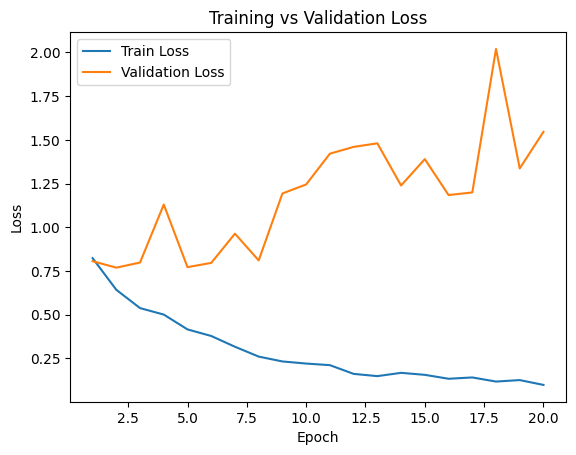

In [6]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

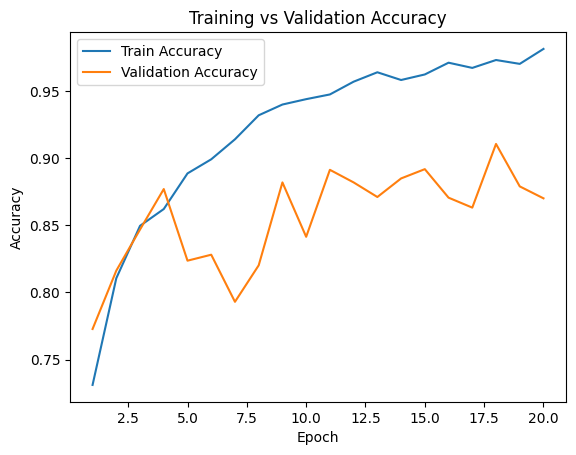

In [7]:
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

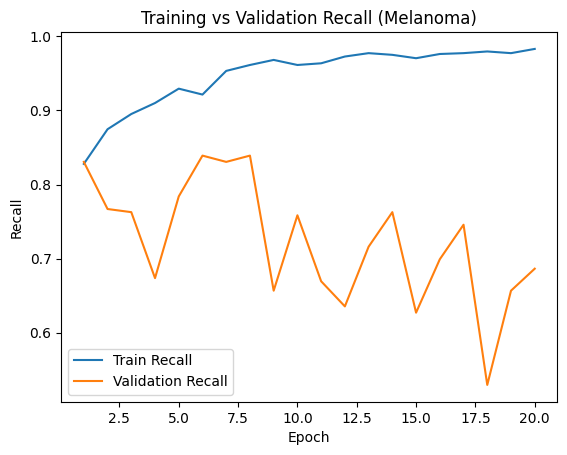

In [8]:
plt.figure()
plt.plot(epochs, train_recalls, label='Train Recall')
plt.plot(epochs, val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall (Melanoma)')
plt.legend()
plt.show()

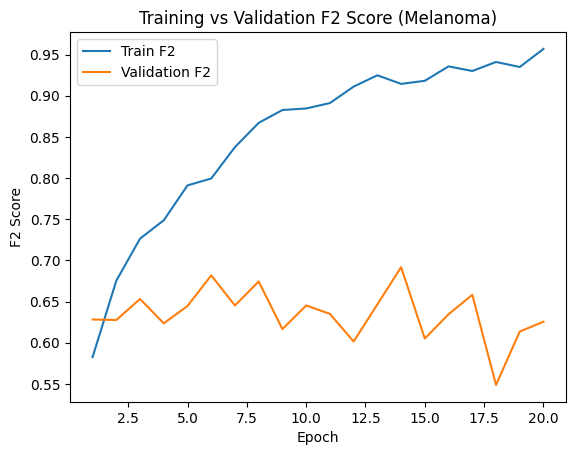

In [9]:
plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2 Score (Melanoma)')
plt.legend()
plt.show()

## Threshold Tuning

In [10]:
import numpy as np
from sklearn.metrics import fbeta_score

model.load_state_dict(torch.load('models/resnet_best.pth', map_location=device))
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}")

Best threshold: 0.51 | Val F2: 0.6939


In [11]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [12]:
cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[1228  112]
 [  64  107]]


[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

In [13]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9505    0.9164    0.9331      1340
           1     0.4886    0.6257    0.5487       171

    accuracy                         0.8835      1511
   macro avg     0.7195    0.7711    0.7409      1511
weighted avg     0.8982    0.8835    0.8896      1511



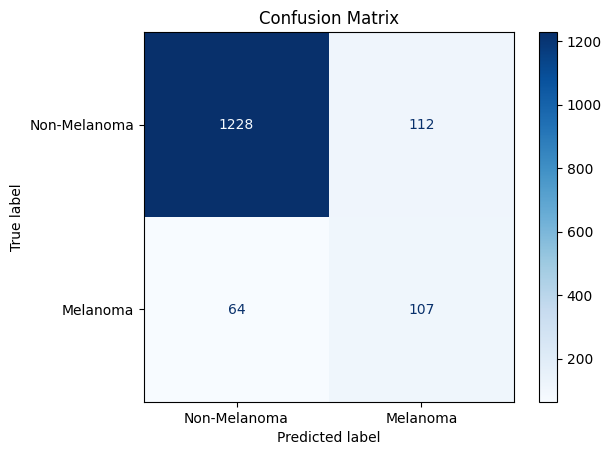

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()